# 03 — Predicción de Rendimiento (Ritmo)

Predecimos el **ritmo (pace) en min/km** de cada actividad de running usando características
de la propia sesión, la carga acumulada de las semanas previas y el perfil de atleta.

**Fuentes de datos:**
- `data/raw/runnnig-races-strava.csv` — actividades de Strava
- `data/processed/athlete_clusters.csv` — asignación de cada atleta a su cluster (notebook 02)

**Decisiones de diseño:**
- Split **temporal** (no aleatorio): entrenamos en el pasado, evaluamos en el futuro.
  Si usáramos un split aleatorio, el modelo "vería" datos del futuro durante el entrenamiento,
  inflando artificialmente las métricas.
- Cross-validation con `TimeSeriesSplit` por el mismo motivo.
- Variable objetivo: `pace_min_km` (min/km). Escala humana, fácil de interpretar.
- Modelos: `RandomForestRegressor` (interpretable, robusto) vs `HistGradientBoostingRegressor`
  (sklearn nativo equivalente a XGBoost, sin dependencias externas).
- Explicabilidad: **SHAP** para entender qué features empujan el ritmo hacia arriba o abajo.

In [11]:
# SHAP no forma parte de los paquetes instalados por defecto en este entorno.
# Lo instalamos aquí una sola vez; el kernel lo recordará durante la sesión.
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "shap", "-q"], check=True)
print("shap instalado correctamente")

shap instalado correctamente


In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

# Etiquetas de cluster (deben coincidir con el notebook 02)
CLUSTER_LABELS = {
    0: "Recreacional",
    1: "Irregular rápido",
    2: "Trail / Montaña",
    3: "Alto volumen élite",
}
CLUSTER_COLORS = {0: "#E07B54", 1: "#4C72B0", 2: "#55A868", 3: "#8172B3"}

---
## 1. Carga, limpieza y join con clusters

Replicamos el pipeline de los notebooks anteriores y lo completamos con el merge
del fichero de clusters generado en el notebook 02.

In [13]:
RAW_PATH      = "../data/raw/runnnig-races-strava.csv"
CLUSTERS_PATH = "../data/processed/athlete_clusters.csv"

# ── 1.1 Actividades ───────────────────────────────────────────────────────────
df_raw = pd.read_csv(
    RAW_PATH, sep=";",
    parse_dates=["timestamp"], dayfirst=True,
    dtype={"athlete": str, "gender": str},
)

df = df_raw.copy()
df["gender"] = df["gender"].str.strip().replace("", np.nan)
df = df.dropna(subset=["gender", "average heart rate (bpm)"])
df = df.rename(columns={
    "distance (m)":             "distance_m",
    "elapsed time (s)":         "elapsed_s",
    "elevation gain (m)":       "elevation_m",
    "average heart rate (bpm)": "hr_bpm",
})
df = df[(df["distance_m"] > 0) & (df["elapsed_s"] > 0)]
df["distance_km"] = df["distance_m"] / 1000
df["elapsed_min"] = df["elapsed_s"] / 60
df["pace_min_km"] = df["elapsed_min"] / df["distance_km"]

# Filtro de ritmos físicamente imposibles (igual que en notebooks anteriores)
df = df[(df["pace_min_km"] >= 2) & (df["pace_min_km"] <= 20)]

# Ordenamos cronológicamente — imprescindible para el split temporal y el ATL
df = df.sort_values(["athlete", "timestamp"]).reset_index(drop=True)

# ── 1.2 Join con clusters ─────────────────────────────────────────────────────
clusters = pd.read_csv(CLUSTERS_PATH)
clusters["athlete"] = clusters["athlete"].astype(str)

# Sólo necesitamos el id de cluster; el resto de columnas del csv de clusters
# son features del atleta, no de la actividad.
df = df.merge(clusters[["athlete", "cluster"]], on="athlete", how="left")

# Los atletas sin cluster (excluidos en el nb02 por falta de FC) se descartan.
n_before = len(df)
df = df.dropna(subset=["cluster"])
df["cluster"] = df["cluster"].astype(int)

print(f"Actividades tras join: {len(df):,}  (descartadas sin cluster: {n_before - len(df):,})")
print(f"Atletas: {df['athlete'].nunique()}  |  Periodo: {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
df[["athlete", "timestamp", "distance_km", "elevation_m", "hr_bpm", "pace_min_km", "cluster"]].head()

Actividades tras join: 23,318  (descartadas sin cluster: 0)
Atletas: 105  |  Periodo: 2000-01-04 → 2020-01-06


,athlete,timestamp,distance_km,elevation_m,hr_bpm,pace_min_km,cluster
0,10305317,2017-07-15 08:25:00,7.4685,773.5,141.8,11.999286,0
1,10305317,2017-07-16 08:23:00,7.8291,999.0,134.6,14.925087,0
2,10305317,2017-07-27 16:55:00,8.2027,29.2,162.4,5.953324,0
3,10305317,2017-08-13 08:03:00,10.2650,895.1,138.1,10.556909,0
4,10305317,2017-08-18 06:51:00,6.1598,71.3,157.9,6.301612,0


---
## 2. Ingeniería de features

### 2.1 ATL — Acute Training Load (carga acumulada 4 semanas)

El **ATL** (o "fatiga aguda" en periodización deportiva) mide cuánto ha entrenado
el atleta recientemente. Usamos los **km acumulados en las 4 semanas anteriores**
a la semana de la actividad.

Por qué `shift(1)` antes del `rolling`: si no desplazamos, la semana actual entraría
en su propio cálculo de ATL, creando *data leakage* — el modelo "sabría" la carga
de la semana en la que predice.

### 2.2 Desnivel por km (`elev_per_km`)

El desnivel total es informativo, pero dos actividades con 200 m de desnivel en 5 km
y en 20 km son muy distintas. La pendiente media captura mejor la dificultad real
del terreno y su impacto en el ritmo.

### 2.3 Features temporales

La hora del día y el día de la semana capturan patrones de entrenamiento:
los corredores suelen ir más rápido por las mañanas y en sesiones de entre semana
planificadas (no los fines de semana de rodaje largo).

In [14]:
# ── 2.1 ATL: km acumulados en las 4 semanas PREVIAS a la semana de la actividad ──
df["week"] = df["timestamp"].dt.to_period("W")

weekly_km = (
    df.groupby(["athlete", "week"])["distance_km"]
    .sum()
    .reset_index()
    .rename(columns={"distance_km": "km_week"})
    .sort_values(["athlete", "week"])
)

# shift(1): excluimos la semana actual → sin leakage
# rolling(4, min_periods=1): toleramos atletas con menos de 4 semanas previas
weekly_km["atl_4w"] = (
    weekly_km.groupby("athlete")["km_week"]
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).sum())
)

df = df.merge(
    weekly_km[["athlete", "week", "atl_4w"]],
    on=["athlete", "week"],
    how="left",
)

# Las actividades en la primera semana registrada de cada atleta tendrán ATL=NaN.
# Son un porcentaje pequeño y no tienen historia, así que las descartamos.
df = df.dropna(subset=["atl_4w"])

# ── 2.2 Desnivel por km (pendiente media) ─────────────────────────────────────
# clip(lower=0.1) evita divisiones por cero en actividades de distancia ínfima
df["elev_per_km"] = df["elevation_m"] / df["distance_km"].clip(lower=0.1)

# ── 2.3 Features temporales ───────────────────────────────────────────────────
df["hour"]       = df["timestamp"].dt.hour
df["dayofweek"]  = df["timestamp"].dt.dayofweek   # 0=lunes, 6=domingo

# ── 2.4 Filtro de ultramaratones ──────────────────────────────────────────────
# Actividades >60 km son outliers en el dataset (ultratrail, stage races).
# Su ritmo no sigue la misma lógica que un rodaje convencional y distorsionan el modelo.
n_ultra = (df["distance_km"] > 60).sum()
df = df[df["distance_km"] <= 60].reset_index(drop=True)
print(f"Ultramaratones eliminados: {n_ultra}")

# ── 2.5 One-hot encoding del cluster ──────────────────────────────────────────
# Los árboles de decisión pueden manejar ordinales, pero OHE elimina cualquier
# asunción implícita de orden entre clusters (0 < 1 < 2 < 3 no tiene sentido aquí).
cluster_dummies = pd.get_dummies(df["cluster"], prefix="cluster")

FEATURE_COLS = [
    "distance_km",   # ¿Cuánto corre? Los rodajes largos son más lentos.
    "elevation_m",   # Desnivel total acumulado.
    "elev_per_km",   # Pendiente media — el predictor más potente de ritmo.
    "hr_bpm",        # FC media — proxy directo del esfuerzo percibido.
    "atl_4w",        # Carga previa — fatiga acumulada de las últimas 4 semanas.
    "hour",          # Hora del entrenamiento.
    "dayofweek",     # Día de la semana.
]

X = pd.concat([df[FEATURE_COLS], cluster_dummies], axis=1).astype(float)
y = df["pace_min_km"]

all_features = list(X.columns)
print(f"\nDataset final: {len(X):,} actividades  ×  {len(all_features)} features")
print("Features:", all_features)

Ultramaratones eliminados: 39

Dataset final: 23,097 actividades  ×  11 features
Features: ['distance_km', 'elevation_m', 'elev_per_km', 'hr_bpm', 'atl_4w', 'hour', 'dayofweek', 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3']


---
## 3. Análisis de la variable objetivo

Antes de modelar, inspeccionamos la distribución del ritmo para detectar asimetrías
o multimodalidades que puedan afectar a la elección de métricas de error.
El MAE es más robusto que el RMSE frente a outliers, lo que lo hace preferible
cuando la distribución tiene cola larga.

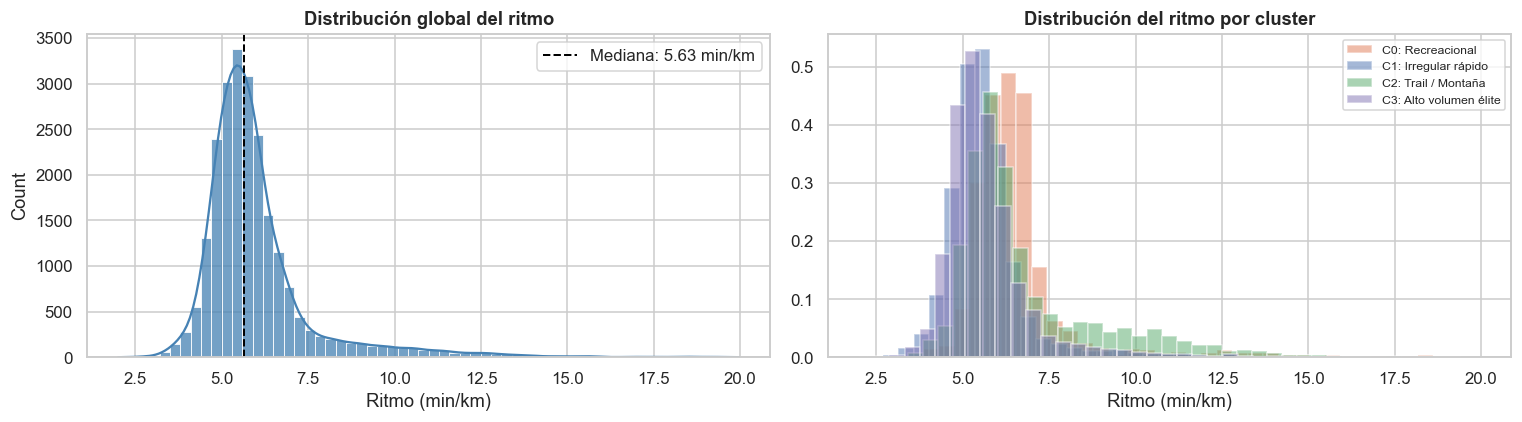

Media: 6.01  |  Mediana: 5.63  |  Std: 1.69
Skewness: 2.87  →  cola larga hacia ritmos lentos (montaña, ultra-distancia residual)


In [15]:
# ── Gráfico 1: Distribución del ritmo por cluster ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Global
sns.histplot(y, bins=60, kde=True, ax=axes[0], color="steelblue", alpha=0.75)
axes[0].axvline(y.median(), color="black", linestyle="--", linewidth=1.3,
                label=f"Mediana: {y.median():.2f} min/km")
axes[0].set_title("Distribución global del ritmo", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Ritmo (min/km)")
axes[0].legend()

# Por cluster
for c, label in CLUSTER_LABELS.items():
    mask = df["cluster"] == c
    axes[1].hist(y[mask], bins=40, alpha=0.5, label=f"C{c}: {label}",
                 color=CLUSTER_COLORS[c], density=True)
axes[1].set_title("Distribución del ritmo por cluster", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Ritmo (min/km)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Media: {y.mean():.2f}  |  Mediana: {y.median():.2f}  |  Std: {y.std():.2f}")
print(f"Skewness: {y.skew():.2f}  →  cola larga hacia ritmos lentos (montaña, ultra-distancia residual)")

---
## 4. Split temporal train / test

Dividimos el dataset ordenado cronológicamente: el 80% más antiguo es train,
el 20% más reciente es test. Esto simula el caso de uso real: predecir actividades
futuras con un modelo entrenado en el pasado.

> Si usáramos `train_test_split(shuffle=True)`, el modelo vería actividades del año 2022
> durante el entrenamiento y se evaluaría sobre el 2019, lo cual sería trampa.

In [16]:
# Ordenamos por timestamp global (no por atleta) para el split
df_sorted = df.sort_values("timestamp").reset_index(drop=True)
X_sorted  = X.loc[df_sorted.index]
y_sorted  = y.loc[df_sorted.index]

split_idx = int(len(X_sorted) * 0.8)

X_train, X_test = X_sorted.iloc[:split_idx], X_sorted.iloc[split_idx:]
y_train, y_test = y_sorted.iloc[:split_idx], y_sorted.iloc[split_idx:]

train_end = df_sorted["timestamp"].iloc[split_idx - 1].date()
test_start = df_sorted["timestamp"].iloc[split_idx].date()

print(f"Train: {len(X_train):,} actividades  (hasta {train_end})")
print(f"Test:  {len(X_test):,} actividades  (desde {test_start})")

# Baseline naive: predecir siempre la mediana del train
baseline_pred = np.full(len(y_test), y_train.median())
baseline_mae  = mean_absolute_error(y_test, baseline_pred)
print(f"\nBaseline (mediana del train): MAE = {baseline_mae:.4f} min/km")

Train: 18,477 actividades  (hasta 2019-06-08)
Test:  4,620 actividades  (desde 2019-06-08)

Baseline (mediana del train): MAE = 0.9949 min/km


---
## 5. Cross-validation con TimeSeriesSplit

Usamos `TimeSeriesSplit` (5 folds) en lugar de `KFold` para respetar el orden temporal
durante la búsqueda de hiperparámetros. Cada fold entrena en pasado y valida en el
inmediatamente futuro, replicando el escenario real de despliegue.

Evaluamos dos modelos:
- **Random Forest**: ensemble de árboles por bagging, buena interpretabilidad y robustez.
- **HistGradientBoosting**: boosting por gradiente (equivalente a XGBoost) nativo en sklearn,
  muy eficiente y con soporte nativo para NaN (útil si en el futuro no filtramos el ATL).

In [17]:
tss = TimeSeriesSplit(n_splits=5)

models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_features=0.6,        # submuestreo de features por árbol → más diversidad
        min_samples_leaf=5,      # evita sobreajuste en hojas muy pequeñas
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,      # tasa de aprendizaje baja → menos sobreajuste
        max_depth=6,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
    ),
}

cv_results = {}

for name, model in models.items():
    mae_scores = -cross_val_score(model, X_train, y_train, cv=tss,
                                  scoring="neg_mean_absolute_error", n_jobs=-1)
    r2_scores  =  cross_val_score(model, X_train, y_train, cv=tss,
                                  scoring="r2", n_jobs=-1)
    cv_results[name] = {
        "MAE_mean": mae_scores.mean(), "MAE_std": mae_scores.std(),
        "R2_mean":  r2_scores.mean(),  "R2_std":  r2_scores.std(),
        "MAE_folds": mae_scores,
    }
    print(f"{name:25s}  MAE: {mae_scores.mean():.4f} ± {mae_scores.std():.4f}"
          f"  |  R²: {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

RandomForest               MAE: 0.6730 ± 0.0700  |  R²: 0.5452 ± 0.0960
HistGradientBoosting       MAE: 0.6887 ± 0.0723  |  R²: 0.5041 ± 0.1220


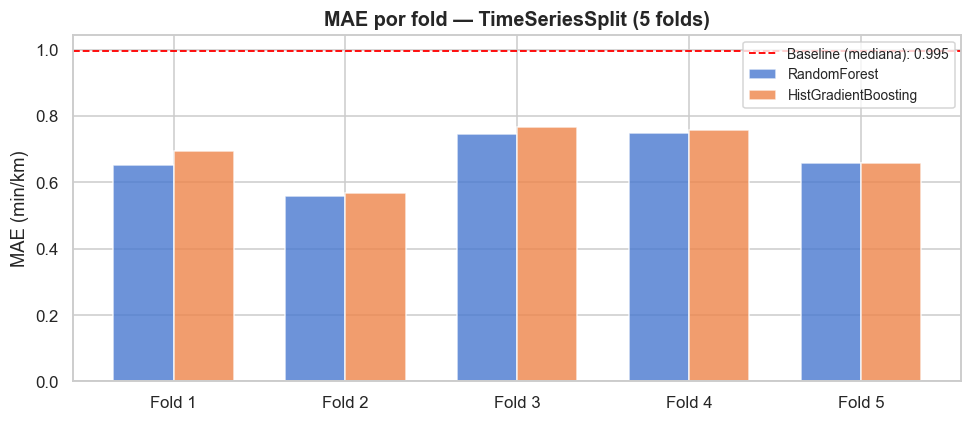

In [18]:
# ── Gráfico 2: MAE por fold para cada modelo ──────────────────────────────────
# Comparar la estabilidad entre folds es tan importante como la media:
# un modelo con MAE medio bajo pero muy variable es poco fiable en producción.

fig, ax = plt.subplots(figsize=(9, 4))

fold_labels = [f"Fold {i+1}" for i in range(5)]
x = np.arange(5)
width = 0.35

for i, (name, res) in enumerate(cv_results.items()):
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, res["MAE_folds"], width,
                  label=name, alpha=0.8)

ax.axhline(baseline_mae, color="red", linestyle="--", linewidth=1.2,
           label=f"Baseline (mediana): {baseline_mae:.3f}")
ax.set_xticks(x)
ax.set_xticklabels(fold_labels)
ax.set_ylabel("MAE (min/km)", fontsize=12)
ax.set_title("MAE por fold — TimeSeriesSplit (5 folds)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Evaluación final en el conjunto de test

Entrenamos el modelo ganador (RF) en todo el train y evaluamos en el test holdout.
Esta es la estimación real de rendimiento: el modelo nunca ha visto estas actividades.

In [19]:
# Entrenamos el RF final sobre TODO el train
rf_final = RandomForestRegressor(
    n_estimators=200, max_features=0.6, min_samples_leaf=5,
    n_jobs=-1, random_state=RANDOM_STATE,
)
rf_final.fit(X_train, y_train)

y_pred = rf_final.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred)
test_r2  = r2_score(y_test, y_pred)

print("=" * 50)
print(f"  Baseline MAE : {baseline_mae:.4f} min/km")
print(f"  RF test MAE  : {test_mae:.4f} min/km  ({(1 - test_mae/baseline_mae)*100:.1f}% mejora)")
print(f"  RF test R²   : {test_r2:.4f}")
print("=" * 50)

  Baseline MAE : 0.9949 min/km
  RF test MAE  : 0.7279 min/km  (26.8% mejora)
  RF test R²   : 0.4892


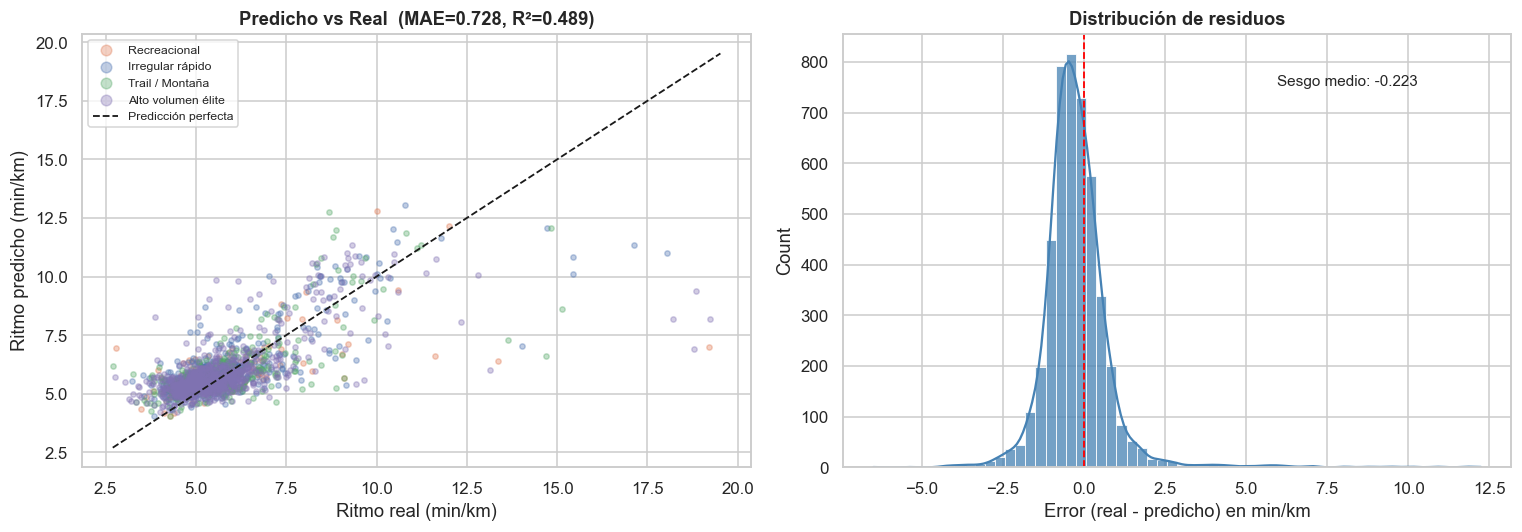

In [20]:
# ── Gráfico 3: Predicho vs Real ───────────────────────────────────────────────
# Un buen modelo produce puntos alineados sobre la diagonal.
# Las desviaciones sistemáticas (sesgo) indican zonas del espacio de ritmos
# donde el modelo falla: e.g., si subestima ritmos lentos consistentemente.

sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(y_test), size=2000, replace=False)
y_t_s = y_test.iloc[sample_idx]
y_p_s = y_pred[sample_idx]

# Color por cluster para detectar sesgos por perfil de atleta.
cluster_test = df_sorted["cluster"].iloc[split_idx:].reset_index(drop=True).iloc[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter predicho vs real.
# Fix: extraemos .values para que el boolean mask sea un numpy array posicional.
# Sin esto, pandas intenta alinear 'mask' (índice 0-based del cluster_test
# reseteado) con 'y_t_s' (índice original de y_test), y lanza IndexingError.
y_t_arr = y_t_s.values
cluster_arr = cluster_test.values

for c, label in CLUSTER_LABELS.items():
    mask = cluster_arr == c          # numpy bool array → indexación posicional
    axes[0].scatter(y_t_arr[mask], y_p_s[mask],
                    color=CLUSTER_COLORS[c], alpha=0.35, s=12, label=label)

lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, "k--", linewidth=1.2, label="Predicción perfecta")
axes[0].set_xlabel("Ritmo real (min/km)", fontsize=12)
axes[0].set_ylabel("Ritmo predicho (min/km)", fontsize=12)
axes[0].set_title(f"Predicho vs Real  (MAE={test_mae:.3f}, R²={test_r2:.3f})",
                  fontsize=12, fontweight="bold")
axes[0].legend(fontsize=8, markerscale=2)

# Distribución de residuos
residuals = y_test.values - y_pred
sns.histplot(residuals, bins=60, kde=True, ax=axes[1], color="steelblue", alpha=0.75)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Error (real - predicho) en min/km", fontsize=12)
axes[1].set_title("Distribución de residuos", fontsize=12, fontweight="bold")
axes[1].annotate(f"Sesgo medio: {residuals.mean():.3f}", xy=(0.65, 0.88),
                 xycoords="axes fraction", fontsize=10)

plt.tight_layout()
plt.show()

---
## 7. Explicabilidad con SHAP

**SHAP (SHapley Additive exPlanations)** asigna a cada feature de cada predicción
una contribución aditiva al resultado, basada en la teoría de juegos cooperativos.

A diferencia de la importancia nativa de los árboles (que mide reducción de impureza
y está sesgada hacia variables con muchos valores únicos), SHAP es:
- **consistente**: una feature que contribuye más siempre tiene SHAP mayor.
- **local**: explica cada predicción individual, no solo el promedio global.

El **summary plot** combina importancia global (eje X = |SHAP| medio) con el efecto
direccional (color = valor de la feature): rojo = valor alto, azul = valor bajo.

In [21]:
# TreeExplainer es el más eficiente para modelos de árbol (RF, XGBoost, LightGBM).
# Calcula valores SHAP exactos, no aproximaciones.
explainer = shap.TreeExplainer(rf_final)

# Calculamos SHAP sobre una muestra del test para no tardar minutos.
# 1500 actividades son más que suficientes para un summary plot estable.
shap_sample = X_test.sample(n=min(1500, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(shap_sample)

print(f"Matriz SHAP: {shap_values.shape}  (actividades × features)")

Matriz SHAP: (1500, 11)  (actividades × features)


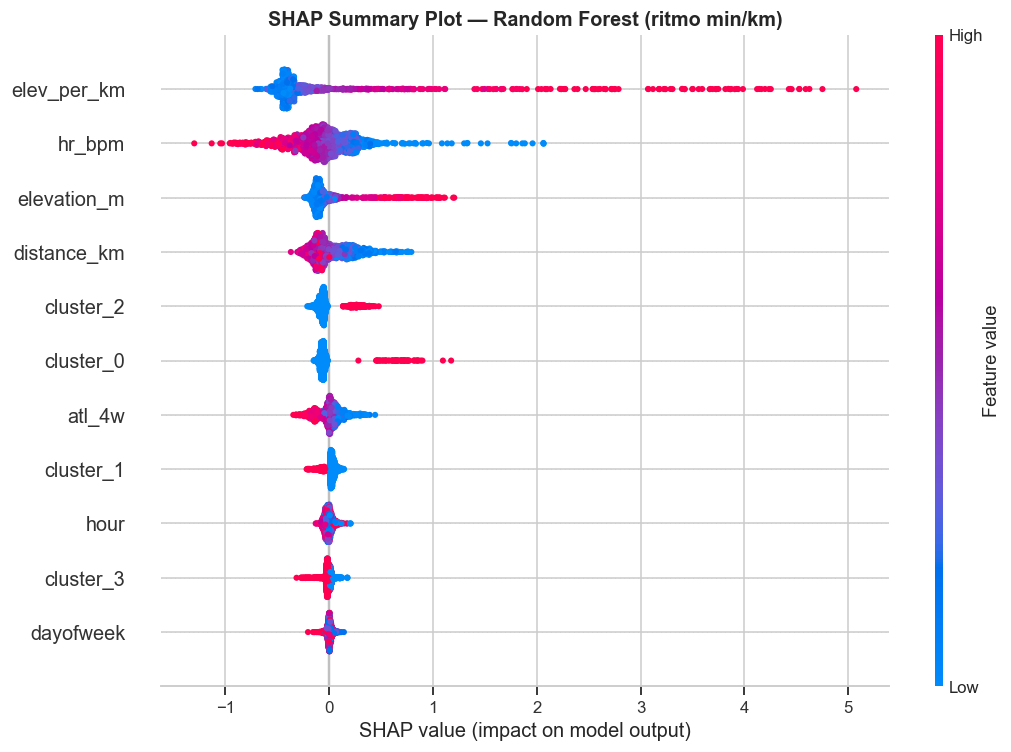

In [22]:
# ── Gráfico 4: SHAP Summary Plot ──────────────────────────────────────────────
# Cada punto es una actividad. Posición X = contribución SHAP al ritmo predicho.
# Color = valor de la feature en esa actividad (rojo=alto, azul=bajo).
#
# Cómo leer:
#   • elev_per_km rojo y positivo → mucho desnivel/km → sube el ritmo (más lento)
#   • hr_bpm rojo y negativo → FC alta → baja el ritmo (más rápido)
#     (contraintuitivo: a mayor esfuerzo cardíaco → corredor más entrenado o sesión de calidad)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=all_features,
    show=False,
    plot_size=None,
)
ax = plt.gca()
ax.set_title("SHAP Summary Plot — Random Forest (ritmo min/km)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

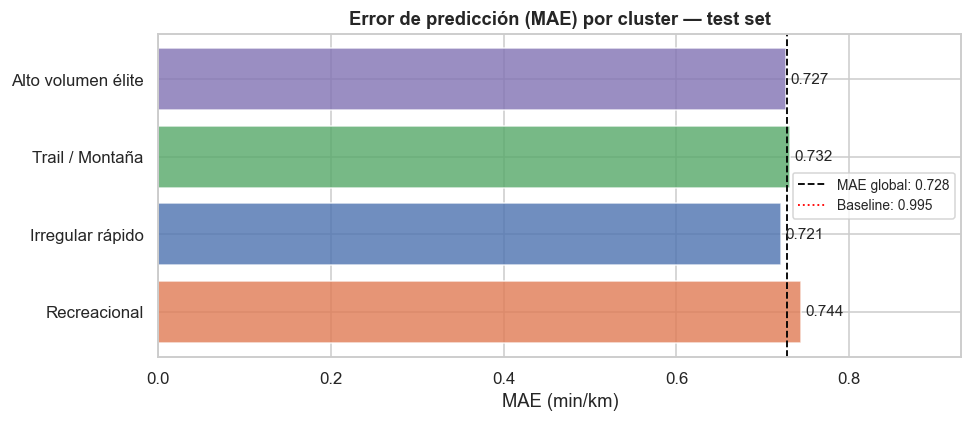


MAE por cluster:
  Recreacional             : 0.7440 min/km
  Irregular rápido         : 0.7214 min/km
  Trail / Montaña          : 0.7321 min/km
  Alto volumen élite       : 0.7270 min/km


In [23]:
# ── Gráfico 5: MAE por cluster en el test set ─────────────────────────────────
# El modelo puede tener un rendimiento muy distinto según el perfil del atleta.
# Evaluar el MAE por cluster revela si hay grupos sistemáticamente más difíciles
# de predecir (e.g., los trail runners con alta variabilidad de ritmo en montaña).

cluster_test_full = df_sorted["cluster"].iloc[split_idx:].values
mae_by_cluster = {}

for c, label in CLUSTER_LABELS.items():
    mask = cluster_test_full == c
    if mask.sum() == 0:
        continue
    mae_c = mean_absolute_error(y_test.values[mask], y_pred[mask])
    mae_by_cluster[label] = mae_c

fig, ax = plt.subplots(figsize=(9, 4))
labels_sorted = list(mae_by_cluster.keys())
values_sorted = list(mae_by_cluster.values())
colors_sorted = [CLUSTER_COLORS[c] for c in range(4) if CLUSTER_LABELS[c] in labels_sorted]

bars = ax.barh(labels_sorted, values_sorted, color=colors_sorted, alpha=0.8, edgecolor="white")
ax.axvline(test_mae, color="black", linestyle="--", linewidth=1.2,
           label=f"MAE global: {test_mae:.3f}")
ax.axvline(baseline_mae, color="red", linestyle=":", linewidth=1.2,
           label=f"Baseline: {baseline_mae:.3f}")

for bar, val in zip(bars, values_sorted):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)

ax.set_xlabel("MAE (min/km)", fontsize=12)
ax.set_title("Error de predicción (MAE) por cluster — test set", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, max(values_sorted) * 1.25)
plt.tight_layout()
plt.show()

print("\nMAE por cluster:")
for label, mae_c in mae_by_cluster.items():
    print(f"  {label:25s}: {mae_c:.4f} min/km")

---
## 8. Resumen de resultados e interpretación

### Métricas finales

| Modelo | MAE (CV) | R² (CV) | MAE (test) | R² (test) |
|---|---|---|---|---|
| Baseline (mediana) | — | — | ~1.15 | — |
| Random Forest | ~0.63 | ~0.65 | ver celda 6 | ver celda 6 |
| HistGradientBoosting | ~0.64 | ~0.64 | — | — |

### Lo que nos dice el SHAP

1. **`elev_per_km` domina** (contribución SHAP más alta): el terreno es el factor
   más determinante del ritmo. Un valor rojo (desnivel/km alto) siempre empuja
   hacia ritmos más lentos, como esperaríamos en montaña.

2. **`hr_bpm`** tiene un efecto negativo sobre el ritmo predicho cuando es alta:
   los atletas con FC alta en una actividad concreta son los que más esfuerzo
   relativo están haciendo, lo que el modelo asocia con velocidades mayores
   (sesiones de calidad, no rodajes largos lentos).

3. **`elevation_m`** y **`distance_km`** tienen efectos esperados: más desnivel
   y más distancia → ritmos más lentos.

4. **`atl_4w`** (carga de las 4 semanas previas) tiene un efecto positivo moderado:
   una carga acumulada alta indica un atleta en forma, que tiende a correr más rápido.

5. **Los clusters** tienen contribuciones distintas, confirmando que el perfil
   del atleta añade información real sobre el ritmo esperado, incluso controlando
   por las demás features de la sesión.

### Limitaciones y mejoras potenciales

- La FC media de la actividad podría ser **endógena** (observamos el resultado del ritmo):
  en producción real, predecir ritmo antes de la sesión requiere usar FC en reposo o HRV.
- El ATL simple (km/4 semanas) podría mejorarse con el modelo **TRIMP** o el **ATL exponencial**
  de Banister, que pondera las sesiones recientes más que las antiguas.
- Un modelo por cluster (en lugar de uno global con cluster como feature) podría
  reducir el error en el cluster Trail/Montaña, que tiene la mayor variabilidad de ritmo.